In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
file_path = f'./raw_data_excel/final_tune1_v2_no_conf.xlsx'
df = pd.read_excel(file_path)
df = df.drop(['illegal','file_name'], axis=1)
# df = df.loc[df['speed'] != 'learning']
# df['datetime'] = pd.to_datetime(df['datetime'])
print(df.count())
print("="*70)
df.info()


id           377
type         377
direction    377
speed        377
datetime     377
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         377 non-null    int64
 1   type       377 non-null    int64
 2   direction  377 non-null    str  
 3   speed      377 non-null    str  
 4   datetime   377 non-null    str  
dtypes: int64(2), str(3)
memory usage: 14.9 KB


In [42]:
df.tail(1)

,id,type,direction,speed,datetime
376,890,1,down,147.50111863430277,2026-02-26_21:41:25


In [43]:
# # names: {0: 'Center_Barrier', 1: 'Line', 2: 'Truck', 3: 'bus', 4: 'car'}
# df.loc[df['type'] == 4,'type'] = 'car'
# df.loc[df['type'] == 3, 'type'] = 'bus'
# df.loc[df['type'] == 2, 'type'] = 'truck'
# df.info()
# Classes: {0: 'bus', 1: 'car', 2: 'motorcycle', 3: 'people', 4: 'person', 5: 'truck'}
# coco 번호 자동차 2, 버스 5, 트럭 7, 오토바이 3,  yolo11n
car = 1
bus = 0
truck = 4   #fdsafsafklsa;fkl;fd
person = 4  
people = 3

#  ohghgfhfgfdfsasfrsion
# truck = 2
# bus = 3
# car=4
# no tune_old
# truck = 0
# bus = 1
# car=2


# car = 2
# bus = 5
# truck = 7
# motorcycle = 3
# 자동차 차량수 down 
car_down_num = df[(df['type'] == car) & (df['direction'] == 'down')].count()
# car_down_num = df[(df['type'] == car)].count()
print("자동차 차량수 down :", car_down_num)

# 자동차 차량수 up 
car_up_num = df[(df['type'] == car) & (df['direction'] == 'up')].count()
# car_up_num = df[(df['type'] == car)].count()
print("자동차 차량수 up :", car_up_num)

total = car_down_num + car_up_num
print(total)


자동차 차량수 down : id           179
type         179
direction    179
speed        179
datetime     179
dtype: int64
자동차 차량수 up : id           197
type         197
direction    197
speed        197
datetime     197
dtype: int64
id           376
type         376
direction    376
speed        376
datetime     376
dtype: int64


In [44]:
# bus 차량수 down 
bus_down_num = df[(df['type'] == bus) & (df['direction'] == 'down')].count()

print("버스 차량수 down :", bus_down_num)

# 버스 차량수 up 
bus_up_num = df[(df['type'] == bus) & (df['direction'] == 'up')].count()

print("버스 차량수 down :", bus_up_num)
total_bus = bus_down_num + bus_up_num
print(total_bus)


버스 차량수 down : id           1
type         1
direction    1
speed        1
datetime     1
dtype: int64
버스 차량수 down : id           0
type         0
direction    0
speed        0
datetime     0
dtype: int64
id           1
type         1
direction    1
speed        1
datetime     1
dtype: int64


In [45]:
# truck 차량수 down 
truck_down_num = df[(df['type'] == truck) & (df['direction'] == 'down')].count()

print("트럭 차량수 down :", truck_down_num)

# truck 차량수 up 
truck_up_num = df[(df['type'] == truck) & (df['direction'] == 'up')].count()

print("트럭 차량수 up :", truck_up_num)
total_truck = truck_down_num + truck_up_num
print(total_truck)

트럭 차량수 down : id           0
type         0
direction    0
speed        0
datetime     0
dtype: int64
트럭 차량수 up : id           0
type         0
direction    0
speed        0
datetime     0
dtype: int64
id           0
type         0
direction    0
speed        0
datetime     0
dtype: int64


id           310
type         310
direction    310
speed        310
datetime     310
dtype: int64
정상 속도 비율: 85.16%


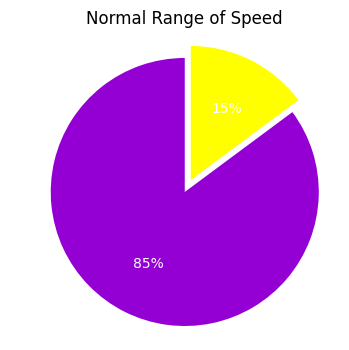

In [46]:
df = df.loc[df['speed'] != 'learning']
print(df.count())

df['speed'] = pd.to_numeric(df['speed'], errors='coerce')
# 1. 데이터가 있는지 확인
if not df.empty:
    # 2. 조건에 맞는 행 개수 세기 (굳이 .loc[..., 'speed']까지 안 써도 됨)
    count: int = len(df[(df['speed'] >= 90) & (df['speed'] <= 130)])
    
    # 3. 비율 계산
    normal_ratio = count / len(df)
else:
    normal_ratio = 0.0

print(f"정상 속도 비율: {normal_ratio:.2%}")
# normal_ratio = len(df.loc[(df['speed'] >= 90) & (df['speed'] <= 130),'speed'])/len(df)
unnormal_ratio = 1 - normal_ratio

plt.figure(figsize=(4,4))
plt.pie(
    [normal_ratio, unnormal_ratio] ,
    labels = ['normal(90-130)', 'unnormal'],
    autopct  = '%1.0f%%',
    startangle = 90,
    explode = (0, 0.1),
    colors = ['darkviolet','yellow'],
    textprops={'color': 'white'}
)

plt.axis('equal')
plt.title('Normal Range of Speed')

plt.savefig(f'image/Normal Range of Speed.png')

plt.show()

In [47]:
# 평균을 통한 속력 정확도 : 54.3%
normal = df.loc[(df['speed'] >= 90) & (df['speed'] <= 130)]
len(normal) / len(df)
normal['speed'].describe()

normal.speed.mean()
sd = normal.groupby('type')['speed'].mean().astype(int)
sd

type
1    110
Name: speed, dtype: int64

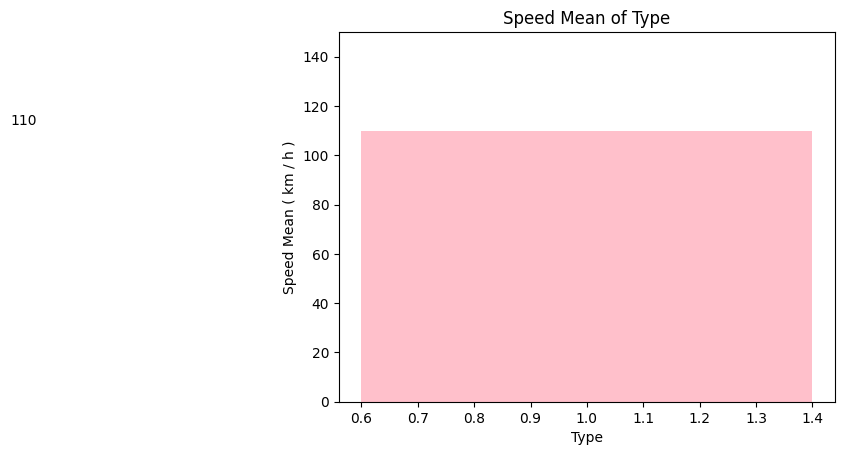

In [48]:
plt.bar(sd.index, sd, color = ['pink','lavender','skyblue'])

plt.title('Speed Mean of Type')
plt.xlabel('Type')
plt.ylabel('Speed Mean ( km / h )')

for i , value in enumerate(sd) :

    plt.text(i, value + 1, str(value), ha = 'center', va = 'bottom', color = 'black', fontsize = 10)

plt.ylim(0,150)


plt.show()